#**Data Exploration using Non-Parametric Methods**


---


Created By: Rakshitha V S (2348448)

Created Date: 21.02.2024

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy.stats import norm, shapiro, ttest_1samp, binom_test,spearmanr,wilcoxon,friedmanchisquare
from statsmodels.graphics.gofplots import qqplot
import scipy.stats as stats

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df=pd.read_csv("/content/drive/MyDrive/TRISEM 3-ML/hotstar.csv")


In [ ]:
df.shape

(6874, 7)

In [ ]:
df.head()

,title,description,genre,year,age_rating,running_time,type
0,Sambha - Aajcha Chawa,A young man sets off on a mission to clean up ...,Action,2012,U/A 16+,141.0,movie
1,Cars Toon: Mater And The Ghostlight,Mater is haunted by a mysterious blue light th...,Animation,2006,U,7.0,movie
2,Kanmani Rambo Khatija,"Unlucky since birth, Rambo finds hope when he ...",Romance,2022,U/A 16+,157.0,movie
3,Butterfly,While trying to rescue her sister's kids from ...,Thriller,2022,U/A 16+,136.0,movie
4,Sister Act,"Rene, a lounge singer, decides to stay at a Ch...",Comedy,1992,U/A 7+,100.0,movie


In [ ]:
df.isnull().sum()

title              0
description        0
genre              0
year               0
age_rating         0
running_time    2306
type               0
dtype: int64

In [ ]:
df = df.dropna()

**Univariate Analysis: Basic descriptive statistics**

In [ ]:
numeric_stats = df.describe()
print(numeric_stats)

              year  running_time
count  4568.000000   4568.000000
mean   2008.719790     98.746716
std      13.266197     49.411142
min    1928.000000      1.000000
25%    2005.000000     70.000000
50%    2012.000000    116.000000
75%    2018.000000    135.000000
max    2023.000000    229.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4568 entries, 0 to 4567
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         4568 non-null   object 
 1   description   4568 non-null   object 
 2   genre         4568 non-null   object 
 3   year          4568 non-null   int64  
 4   age_rating    4568 non-null   object 
 5   running_time  4568 non-null   float64
 6   type          4568 non-null   object 
dtypes: float64(1), int64(1), object(5)
memory usage: 285.5+ KB


**Bivariate Analysis**

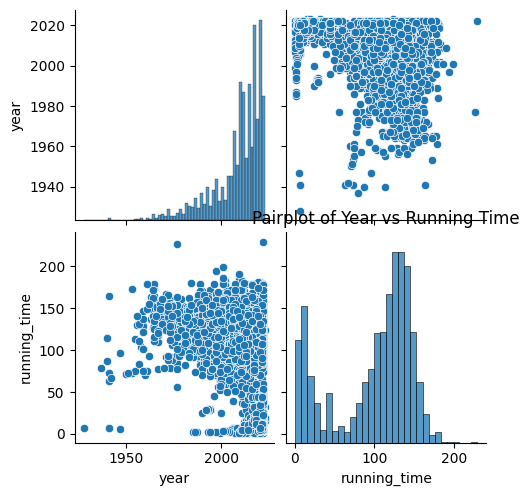

In [ ]:
sns.pairplot(df, vars=['year', 'running_time'])
plt.title('Pairplot of Year vs Running Time')
plt.show()

VIOLIN PLOT :

* to depict the distribution of numeric data across different levels of a categorical variable.
* Comparison of Distributions,
Distributional Characteristics,
Density Estimation,
Outlier Detection,
Data Overlapping,
Combining with Other Plots,
Insights into Skewness and Kurtosis,
Data Exploration.

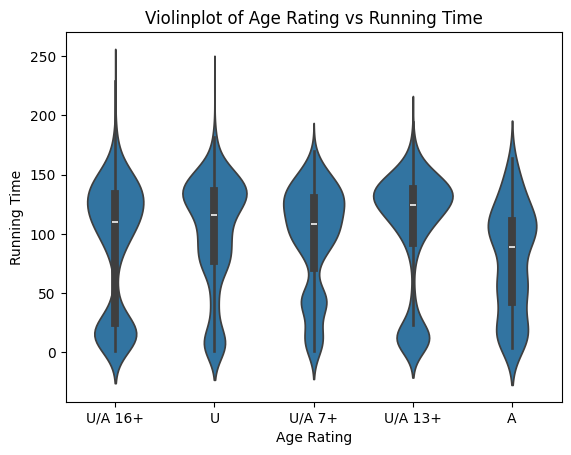

In [ ]:
sns.violinplot(data=df, x='age_rating', y='running_time')
plt.title('Violinplot of Age Rating vs Running Time')
plt.xlabel('Age Rating')
plt.ylabel('Running Time')
plt.show()

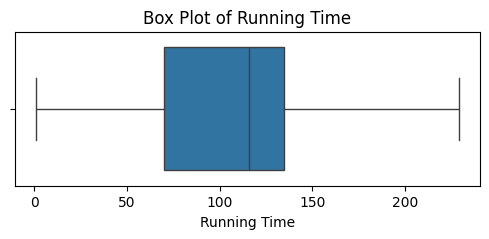

In [ ]:
# Box Plot
plt.figure(figsize=(6, 2))
sns.boxplot(x=df['running_time'])
plt.title('Box Plot of Running Time')
plt.xlabel('Running Time')
plt.show()

In [ ]:
print(df['running_time'])

0       141.0
1         7.0
2       157.0
3       136.0
4       100.0
        ...  
4563    107.0
4564      7.0
4565     93.0
4566     90.0
4567    139.0
Name: running_time, Length: 4568, dtype: float64


In [ ]:
print(df['running_time'].max() )
print(df['running_time'].min())

229.0
1.0


<ipython-input-15-77f94ac5dc72>:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df['running_time'], shade=True,fill=True)


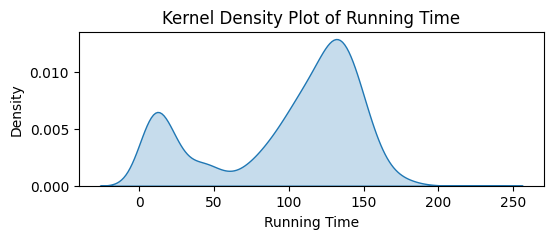

In [ ]:
# Kernel Density Plot
plt.figure(figsize=(6, 2))
sns.kdeplot(df['running_time'], shade=True,fill=True)
plt.title('Kernel Density Plot of Running Time')
plt.xlabel('Running Time')
plt.ylabel('Density')
plt.show()



In [ ]:
correlation_matrix = df[['year', 'running_time']].corr()
print("Correlation Matrix:")
print(correlation_matrix)

Correlation Matrix:
                  year  running_time
year          1.000000     -0.380548
running_time -0.380548      1.000000


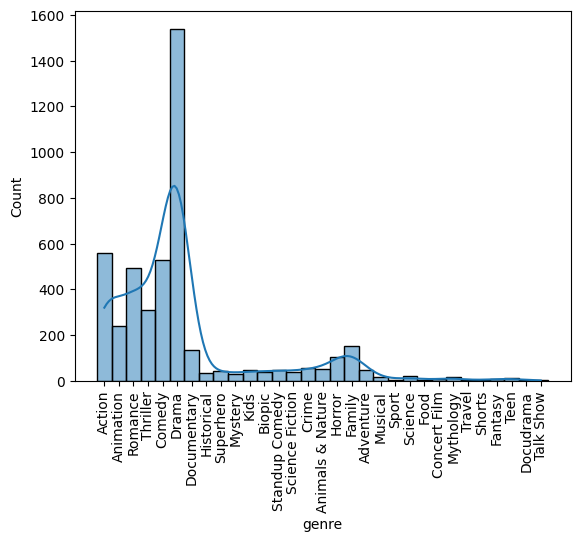

In [ ]:
cht1 = sns.histplot(data=df,x='genre',kde=True)
plt.xticks(rotation=90)
plt.show()

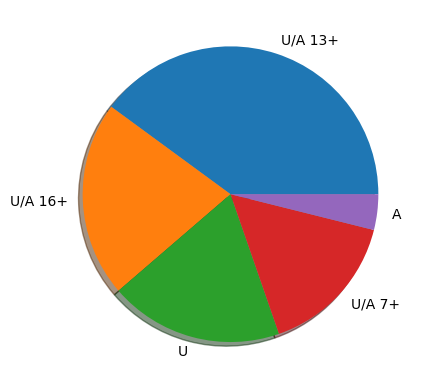

In [ ]:
labels = df['age_rating'].value_counts().index
values = df['age_rating'].value_counts()

plt.pie(x=values,labels=labels,shadow=True)
plt.show()

**Non Parametric Methods**

In [ ]:
sample=df.sample(n=1000)

In [ ]:
sample


,title,description,genre,year,age_rating,running_time,type
3517,Tamashegaagi,"Though happily married, Mohan and Rajesh are w...",Comedy,2007,U/A 16+,145.0,movie
581,Just - A Sad Wrap,"Parting ways due to minute misunderstandings, ...",Drama,2022,U/A 13+,9.0,movie
2965,E,While making a documentary on Alzheimer's dise...,Horror,2017,U/A 13+,103.0,movie
3133,Sudhar Jao,"After the death of his father-in-law, Rajesh t...",Drama,2022,U/A 16+,15.0,movie
151,Hitlist,"Directed by Sasi Mohan, this film stars Rahman...",Drama,1996,U/A 16+,143.0,movie
...,...,...,...,...,...,...,...
108,The Metro,Five friends travelling to Palai to deliver a ...,Thriller,2011,U/A 16+,131.0,movie
2725,Rest House,"Raghu, a great detective with some of the toug...",Thriller,1969,U/A 13+,137.0,movie
4033,Predator 2,A police chief discovers that an invisible cre...,Action,1990,A,107.0,movie
720,Zubaan,"After a bullying incident, Dilsher grows up wi...",Drama,2016,U/A 16+,111.0,movie


**Mann** Whitney U Test

In [ ]:
# compare running times for different genres

#Ho:mean(action_running_time)= mean(romance_running_time)
#H1:mean(action_running_time) != mean(romance_running_time)

action_running_time = df[df['genre'] == 'Action']['running_time']
romance_running_time = df[df['genre'] == 'Romance']['running_time']

mann_whitney_test = stats.mannwhitneyu(action_running_time,romance_running_time)


print("\nMann Whitney U test results: ")
print("U-statistic: ",mann_whitney_test.statistic)
print("p-value: ",mann_whitney_test.pvalue)

p_value = mann_whitney_test.pvalue

alpha = 0.05
if p_value < alpha:
    print("Reject the null hypothesis: There is a significant difference between the running times of the two genres.")
else:
    print("Fail to reject the null hypothesis: There is no significant difference between the running times of the two genres.")


Mann Whitney U test results: 
U-statistic:  152503.5
p-value:  0.0033853438988040003
Reject the null hypothesis: There is a significant difference between the running times of the two genres.


<Axes: xlabel='running_time', ylabel='Density'>

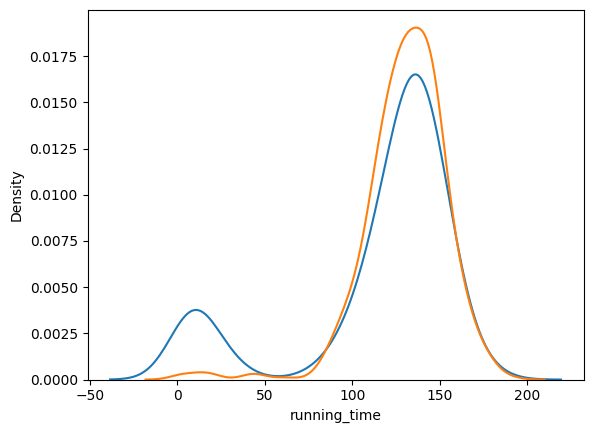

In [ ]:
sns.kdeplot(romance_running_time)
sns.kdeplot(action_running_time)

Spearman rank correlation for assessing monotonic relationships between
numerical variables.

In [ ]:
spearman_corr, p_value = spearmanr(df['year'], df['running_time'])

# To print the correlation coefficient
print("Spearman rank correlation coefficient:", spearman_corr)

# To print the p-value
print("p-value:", p_value)


Spearman rank correlation coefficient: -0.441405249106378
p-value: 3.6115429225210878e-217


the Spearman correlation coefficient is negative, indicating a moderate negative monotonic relationship between the release year and the running time of movies. This suggests that, in general, as the release year increases, there is a tendency for the running time of movies to decrease.

 The small p value means that there is strong evidence to suggest that there is indeed a monotonic relationship between the release year and running time of movies in the dataset.

Since the p-value is greater than the typical significance level of 0.05, we fail to reject the null hypothesis. Therefore, we do not have sufficient evidence to conclude that there are significant differences in running times across the years based on the Friedman test.

# ***Visually concluding the test result and analysis of change in running time over the year***

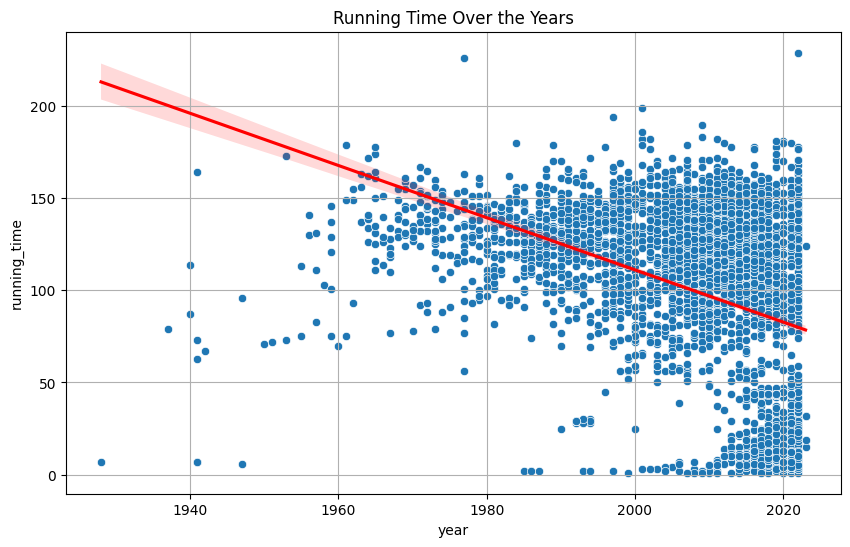

In [ ]:
# Creating a scatter plot of running time over the years
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='year', y='running_time')
plt.title('Running Time Over the Years')
plt.xlabel('Year')
plt.ylabel('Running Time')
plt.grid(True)

# Adding a trend line
sns.regplot(data=df, x='year', y='running_time', scatter=False, color='red')

plt.show()

This trend aligns with the observation of a negative relationship between the release year and running time, as evidenced by the downward slope of the trend line in the scatter plot.


In conclusion, the observed decrease in movie duration over time is indicative of a broader trend towards shorter, more efficient storytelling in response to evolving audience preferences, technological advancements, and economic considerations. This shift underscores the adaptability of the film industry to changing consumer behavior and technological innovations, resulting in the production of films that resonate with contemporary audiences in an increasingly digital and fast-paced world.